## **Install & Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries imported!')

Libraries imported!


In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')        # rows and columns
print(f'Rows: {df.shape[0]}')     # number of customers
print(df.head())                  # first 5 rows
print(df.dtypes)                  # column data types
print(df.describe())              # basic statistics

Shape: (7043, 21)
Rows: 7043
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

In [ ]:
# Check missing values
print(df.isnull().sum())
print(f'Total Missing: {df.isnull().sum().sum()}')
# Fix TotalCharges (has spaces instead of numbers)
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(
    df['TotalCharges'].median(), inplace=True)
# Remove duplicates
print(f'Duplicates: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
# Remove customerID (not useful)
df.drop('customerID', axis=1, inplace=True)
# Convert 0/1 to Yes/No
df['SeniorCitizen'] = df['SeniorCitizen'].map(
    {0: 'No', 1: 'Yes'})
print(f'Shape after cleaning: {df.shape}')
print('Data cleaning complete!')

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Total Missing: 0
Duplicates: 0
Shape after cleaning: (7043, 20)
Data cleaning complete!


Explanation: pd.to_numeric with errors='coerce' converts text to numbers — empty strings become NaN. fillna()
fills missing values with median. We drop customerID because it is just an ID — not useful for analysis.

# Chart 1 — Churn Distribution (Pie Chart)

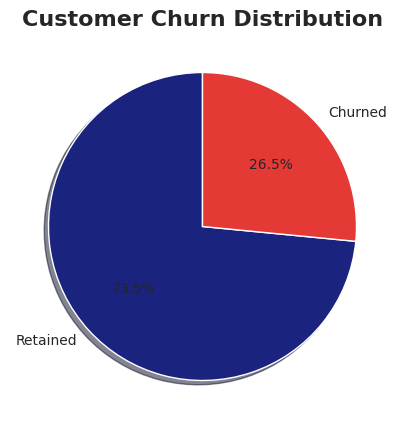

Churn Rate: 26.54%


In [ ]:
plt.figure(figsize=(8, 5))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts,
        labels=['Retained','Churned'],
        autopct='%1.1f%%',
        colors=['#1a237e','#e53935'],
        startangle=90, shadow=True)
plt.title('Customer Churn Distribution',
          fontsize=16, fontweight='bold')
plt.savefig('churn_distribution.png', dpi=150)
plt.show()
print(f"Churn Rate: {(df['Churn']=='Yes').mean()*100:.2f}%")

Explanation: The pie chart shows 26.54% of customers churned. autopct='%1.1f%%' shows percentage on
each pie slice. savefig() saves the chart as an image file.

# Chart 2 — Churn by Contract Type (Bar Chart)

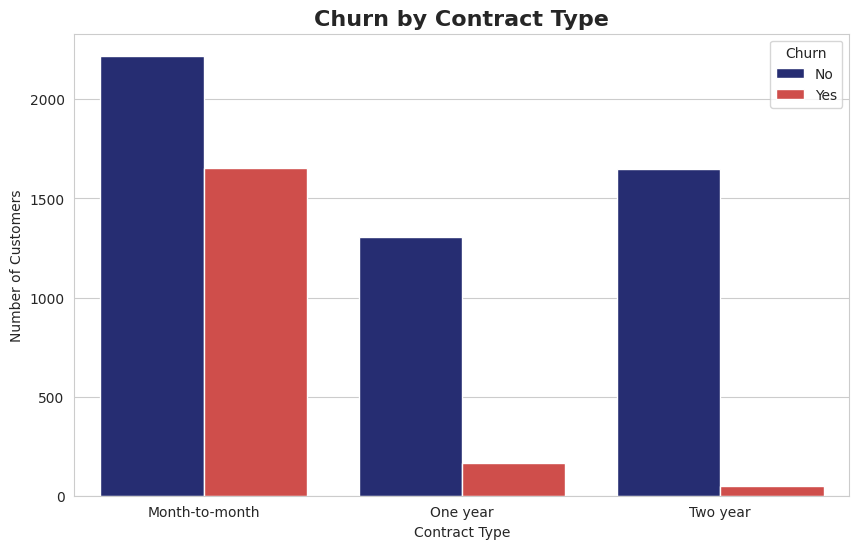

Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: object


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract',
              hue='Churn',
              palette=['#1a237e','#e53935'])
plt.title('Churn by Contract Type',
          fontsize=16, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()
print(df.groupby('Contract')['Churn'].apply(
    lambda x: f"{(x=='Yes').mean()*100:.1f}%"))

Explanation: Month-to-month contracts have 42.7% churn rate! Long-term customers are much more loyal. KEY
INSIGHT: Company should encourage customers to sign longer contracts.

# Chart 3 — Tenure vs Charges (Box Plot)

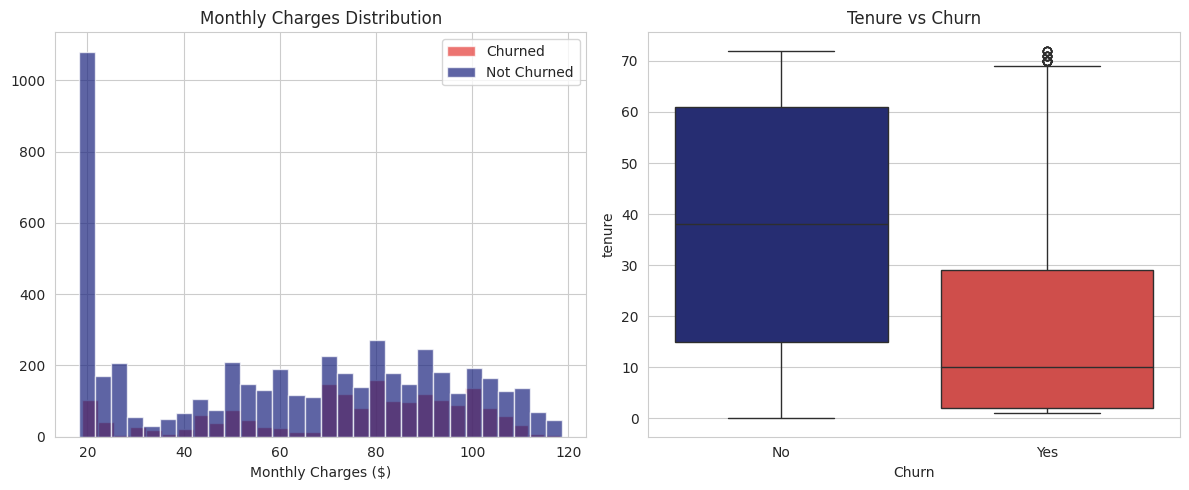

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df[df['Churn']=='Yes']['MonthlyCharges'].hist(
    bins=30, color='#e53935', alpha=0.7, label='Churned')
df[df['Churn']=='No']['MonthlyCharges'].hist(
    bins=30, color='#1a237e', alpha=0.7, label='Not Churned')
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges ($)')
plt.legend()
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Churn', y='tenure',
            palette=['#1a237e','#e53935'])
plt.title('Tenure vs Churn')
plt.tight_layout()
plt.savefig('tenure_charges.png', dpi=150)
plt.show()

Explanation: plt.subplot(1,2,1) creates 2 charts side by side. Churned customers have HIGHER monthly
charges. Churned customers have LOWER tenure — they leave early in their contract.

# Chart 4 — Correlation Heatmap

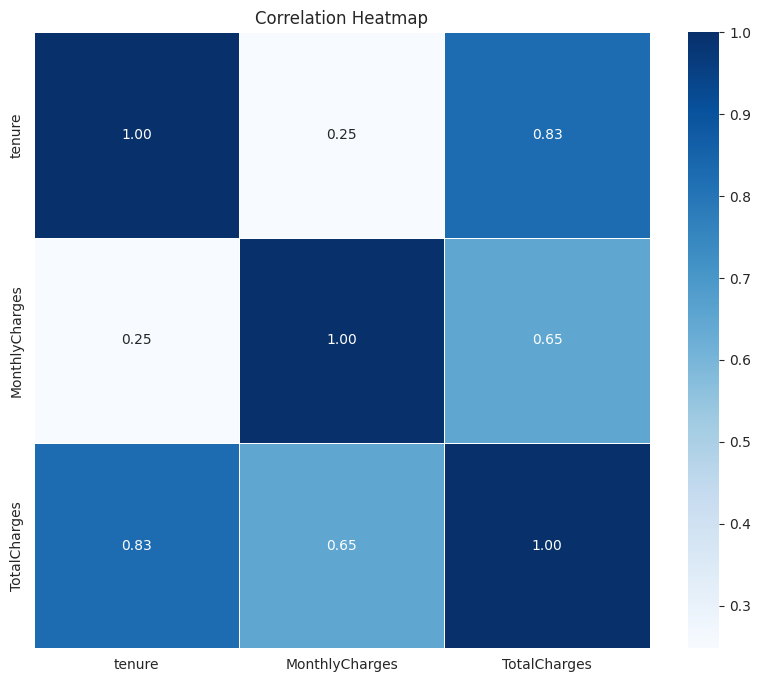

In [ ]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

Explanation: Heatmap shows relationships between numeric columns. Values near 1 = strong positive
relationship. Values near -1 = strong negative relationship. Values near 0 = no relationship.

# KPI Summary & Save Cleaned Data

In [ ]:
total   = len(df)
churned = (df['Churn']=='Yes').sum()
retained= (df['Churn']=='No').sum()
print('='*45)
print('       KPI SUMMARY REPORT')
print('='*45)
print(f'Total Customers     : {total:,}')
print(f'Total Churned       : {churned:,}')
print(f'Churn Rate          : {churned/total*100:.2f}%')
print(f'Retention Rate      : {retained/total*100:.2f}%')
print(f'Avg Monthly Charges : ${df["MonthlyCharges"].mean():.2f}')
print(f'Avg Tenure (months) : {df["tenure"].mean():.1f}')
print('='*45)
df.to_csv('telco_churn_cleaned.csv', index=False)
print('Cleaned data saved!')

       KPI SUMMARY REPORT
Total Customers     : 7,043
Total Churned       : 1,869
Churn Rate          : 26.54%
Retention Rate      : 73.46%
Avg Monthly Charges : $64.76
Avg Tenure (months) : 32.4
Cleaned data saved!
